In [62]:
"""
3D ERT Forward Modeling with MODFLOW Integration
================================================

This example demonstrates the complete workflow for 3D ERT forward modeling
using PyHydroGeophysX, integrating hydrological model outputs.
"""

'\n3D ERT Forward Modeling with MODFLOW Integration\n================================================\n\nThis example demonstrates the complete workflow for 3D ERT forward modeling\nusing PyHydroGeophysX, integrating hydrological model outputs.\n'

# 3D ERT Forward Modeling Workflow with Topography

This example demonstrates 3D ERT forward modeling using PyHydroGeophysX,
integrating MODFLOW hydrological model outputs with realistic topography.

## Workflow Overview

1. **Tutorial**: Learn how to use `mesh_3d.py` module
2. Load MODFLOW water content and porosity data
3. Create 3D mesh with topography and electrode positions
4. Interpolate hydrological properties to 3D mesh
5. Convert water content to resistivity using petrophysical relationships
6. Perform 3D ERT forward modeling
7. Visualize results

---

## Tutorial: Using `mesh_3d.py` for 3D Mesh Creation

The `mesh_3d.py` module provides a `Mesh3DCreator` class with several methods
for creating different types of 3D meshes. Here's a quick reference:

### Key Classes and Functions

| Class/Function | Description |
|----------------|-------------|
| `Mesh3DCreator` | Main class for creating 3D meshes |
| `create_surface_electrode_array()` | Create regular surface electrode grid |
| `create_borehole_electrode_array()` | Create electrodes for borehole |
| `create_crosshole_electrode_array()` | Create multi-borehole electrode setup |
| `create_3d_mesh_with_topography()` | **Create mesh following topography** |
| `apply_topography_to_electrodes()` | Apply surface elevation to electrodes |
| `create_box_mesh()` | Create simple box mesh (flat surface) |
| `create_prism_mesh_from_2d()` | Extrude 2D mesh to 3D prisms |

### Quick Start Examples

```python
from PyHydroGeophysX.core.mesh_3d import Mesh3DCreator

# Initialize mesh creator
creator = Mesh3DCreator(
    mesh_directory='./meshes',
    elec_refinement=0.5,    # Mesh size near electrodes
    node_refinement=2.0,     # Mesh size at boundaries
    attractor_distance=5.0   # Distance for mesh refinement
)

# Example 1: Surface electrode array
electrodes = creator.create_surface_electrode_array(
    nx=10, ny=6,   # Grid size
    dx=5.0, dy=5.0, # Spacing
    x_offset=0, y_offset=0,
    z=0.0  # Surface elevation
)

# Example 2: Apply topography to electrodes
electrodes = creator.apply_topography_to_electrodes(
    electrodes,
    topography_func=lambda x, y: 100 + 0.1*x - 0.05*y  # Example
)

# Example 3: Create 3D mesh with topography
mesh = creator.create_3d_mesh_with_topography(
    electrode_positions=electrodes,
    topography_func=lambda x, y: 100 + 0.1*x,
    para_depth=20.0,
    use_prism_mesh=True
)
```

In [63]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import importlib

# PyGIMLi imports
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert

# Setup package path for development
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

# Import and reload PyHydroGeophysX modules (ensures latest code is used)
import PyHydroGeophysX.core.mesh_3d as mesh_3d_module
importlib.reload(mesh_3d_module)

from PyHydroGeophysX.core.mesh_3d import (
    Mesh3DCreator,
    create_3d_ert_data_container,
    interpolate_modflow_to_3d_mesh
)
from PyHydroGeophysX.petrophysics.resistivity_models import WS_Model

# Optional: PyVista for 3D visualization
try:
    import pyvista as pv
    from pygimli.viewer import pv as pgpv
    PYVISTA_AVAILABLE = True
    pv.set_plot_theme("document")
except ImportError:
    PYVISTA_AVAILABLE = False
    print("PyVista not available. 3D visualization will be limited.")

print(f"PyGIMLi version: {pg.__version__}")
print(f"Mesh3DCreator methods: {[m for m in dir(Mesh3DCreator) if not m.startswith('_')]}")

PyGIMLi version: 1.5.4
Mesh3DCreator methods: ['apply_topography_to_electrodes', 'convert_to_pygimli', 'create_3d_mesh_with_topography', 'create_borehole_electrode_array', 'create_box_mesh', 'create_crosshole_electrode_array', 'create_electrode_grid', 'create_prism_mesh_from_2d', 'create_surface_electrode_array', 'create_surface_mesh_with_topography', 'generate_gmsh_mesh', 'visualize_mesh', 'write_gmsh_geo_file']


Full MODFLOW data shape (nlay, nrow, ncol): (14, 194, 157)
Valid data fraction range: 0.00% to 100.00%

High activity region (>80% active):
  Rows: 0 to 193 (height: 194)
  Cols: 0 to 156 (width: 157)


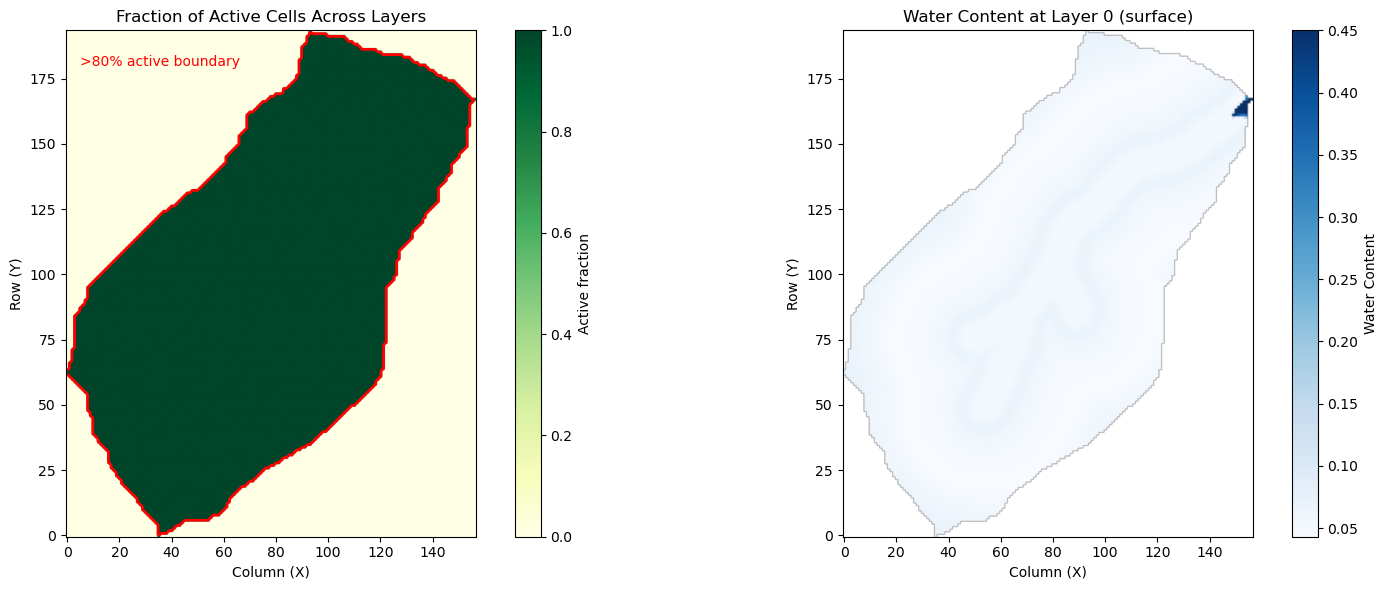


Center of high-activity region: row=96, col=78

Suggested domain placement for 25m x 25m area:
  X offset: 66 to 90
  Y offset: 84 to 108


In [97]:
# Analyze MODFLOW data to find regions with active cells (non-NaN)
# This helps us position the forward modeling domain optimally

data_dir = "data/"
water_content_full = np.load(os.path.join(data_dir, "Watercontent.npy"))
if water_content_full.ndim == 4:
    wc_check = water_content_full[0]  # First timestep
else:
    wc_check = water_content_full

print(f"Full MODFLOW data shape (nlay, nrow, ncol): {wc_check.shape}")
modflow_nlay, modflow_nrow, modflow_ncol = wc_check.shape

# Create a map of valid (non-NaN) cell percentages across the grid
# Average across all layers to see which horizontal areas are most active
valid_fraction = np.zeros((modflow_nrow, modflow_ncol))
for i in range(modflow_nlay):
    valid_fraction += ~np.isnan(wc_check[i, :, :])
valid_fraction /= modflow_nlay

print(f"Valid data fraction range: {valid_fraction.min():.2%} to {valid_fraction.max():.2%}")

# Find regions with high active cell density (>80% active across layers)
high_activity = valid_fraction > 0.8

# Find the bounding box of the high-activity region
rows_active = np.where(np.any(high_activity, axis=1))[0]
cols_active = np.where(np.any(high_activity, axis=0))[0]

if len(rows_active) > 0 and len(cols_active) > 0:
    row_min, row_max = rows_active[0], rows_active[-1]
    col_min, col_max = cols_active[0], cols_active[-1]
    print(f"\nHigh activity region (>80% active):")
    print(f"  Rows: {row_min} to {row_max} (height: {row_max - row_min + 1})")
    print(f"  Cols: {col_min} to {col_max} (width: {col_max - col_min + 1})")

# Visualize the valid data fraction
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot valid fraction map
im = axes[0].imshow(valid_fraction, origin='lower', cmap='YlGn')
axes[0].set_xlabel('Column (X)')
axes[0].set_ylabel('Row (Y)')
axes[0].set_title('Fraction of Active Cells Across Layers')
plt.colorbar(im, ax=axes[0], label='Active fraction')
axes[0].contour(valid_fraction, levels=[0.8], colors='red', linewidths=2)
axes[0].text(5, 180, '>80% active boundary', color='red', fontsize=10)

# Plot water content at layer 0 to see spatial pattern
im2 = axes[1].imshow(wc_check[0, :, :], origin='lower', cmap='Blues')
axes[1].set_xlabel('Column (X)')
axes[1].set_ylabel('Row (Y)')
axes[1].set_title('Water Content at Layer 0 (surface)')
plt.colorbar(im2, ax=axes[1], label='Water Content')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'modflow_active_cells.png'), dpi=150)
plt.show()

# Calculate optimal domain placement
# Find the centroid of the high-activity region
if len(rows_active) > 0 and len(cols_active) > 0:
    # Calculate center of active region
    center_row = (row_min + row_max) // 2
    center_col = (col_min + col_max) // 2
    print(f"\nCenter of high-activity region: row={center_row}, col={center_col}")
    
    # Suggest a smaller domain size that fits well
    suggested_size = 25  # meters (smaller domain)
    print(f"\nSuggested domain placement for {suggested_size}m x {suggested_size}m area:")
    print(f"  X offset: {center_col - suggested_size//2} to {center_col + suggested_size//2}")
    print(f"  Y offset: {center_row - suggested_size//2} to {center_row + suggested_size//2}")

Fully active region stats:
  Number of fully active cells: 16319
  Center (median): row=95, col=77

  20m x 20m domain at center:
    Rows: 85 to 105, Cols: 67 to 87
    Active cell percentage: 100.0%

  25m x 25m domain at center:
    Rows: 83 to 107, Cols: 65 to 89
    Active cell percentage: 100.0%

  30m x 30m domain at center:
    Rows: 80 to 110, Cols: 62 to 92
    Active cell percentage: 100.0%


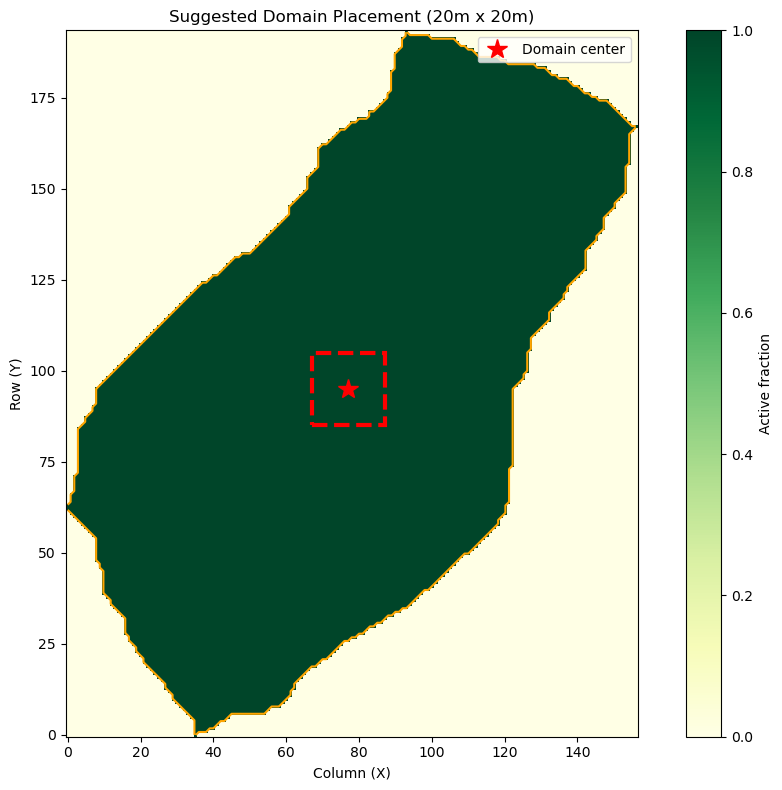


OPTIMAL DOMAIN PARAMETERS:
Domain size: 20m x 20m
Domain offset in MODFLOW grid: x=67, y=85
Domain center in MODFLOW grid: x=77, y=95

Suggested electrode array: 5x5 grid with 4m spacing
  This gives 20m coverage with electrodes at x=[0, 4, 8, 12, 16] and y=[0, 4, 8, 12, 16]


In [98]:
# Find the optimal placement for a smaller domain that is 100% within active cells
# We need ALL cells in the domain to be active (non-NaN)

# Check valid fraction more strictly - we want areas with 100% active cells across all layers
fully_active = valid_fraction == 1.0

# Find the largest rectangular region that is fully active
# For simplicity, let's find the center of mass of the fully active region
rows_full, cols_full = np.where(fully_active)

if len(rows_full) > 0:
    # Center of the fully active region
    center_row_full = int(np.median(rows_full))
    center_col_full = int(np.median(cols_full))
    
    print(f"Fully active region stats:")
    print(f"  Number of fully active cells: {len(rows_full)}")
    print(f"  Center (median): row={center_row_full}, col={center_col_full}")
    
    # Test different domain sizes at the center location
    for domain_size in [20, 25, 30]:
        half = domain_size // 2
        r1, r2 = center_row_full - half, center_row_full + half
        c1, c2 = center_col_full - half, center_col_full + half
        
        # Ensure within bounds
        r1, c1 = max(0, r1), max(0, c1)
        r2, c2 = min(modflow_nrow, r2), min(modflow_ncol, c2)
        
        # Check if this region is fully active
        region_active = fully_active[r1:r2, c1:c2]
        active_pct = np.mean(region_active) * 100
        
        print(f"\n  {domain_size}m x {domain_size}m domain at center:")
        print(f"    Rows: {r1} to {r2}, Cols: {c1} to {c2}")
        print(f"    Active cell percentage: {active_pct:.1f}%")

# Let's visualize where we want to place the domain
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(valid_fraction, origin='lower', cmap='YlGn')
ax.set_xlabel('Column (X)')
ax.set_ylabel('Row (Y)')
ax.set_title('Suggested Domain Placement (20m x 20m)')
plt.colorbar(im, ax=ax, label='Active fraction')

# Draw proposed domain (20m x 20m in the center)
domain_size = 20
half = domain_size // 2
domain_rect = plt.Rectangle(
    (center_col_full - half, center_row_full - half), 
    domain_size, domain_size, 
    fill=False, edgecolor='red', linewidth=3, linestyle='--'
)
ax.add_patch(domain_rect)
ax.plot(center_col_full, center_row_full, 'r*', markersize=15, label='Domain center')

# Also show 80% boundary
ax.contour(valid_fraction, levels=[0.8], colors='orange', linewidths=1.5)

ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'proposed_domain_placement.png'), dpi=150)
plt.show()

# Calculate the optimal parameters for the domain setup
print("\n" + "="*60)
print("OPTIMAL DOMAIN PARAMETERS:")
print("="*60)
print(f"Domain size: {domain_size}m x {domain_size}m")
print(f"Domain offset in MODFLOW grid: x={center_col_full - half}, y={center_row_full - half}")
print(f"Domain center in MODFLOW grid: x={center_col_full}, y={center_row_full}")
print(f"\nSuggested electrode array: 5x5 grid with 4m spacing")
print(f"  This gives 20m coverage with electrodes at x=[0, 4, 8, 12, 16] and y=[0, 4, 8, 12, 16]")

In [64]:
# Create output directory
output_dir = "results/3d_ert_workflow"
os.makedirs(output_dir, exist_ok=True)

## Step 1: Define Domain Geometry and Create Electrodes on Topographic Surface

We'll create a 3D domain with a surface electrode array that follows realistic topography.
This is essential for accurate ERT modeling in areas with significant terrain variation.

In [99]:
# Define domain dimensions (in meters)
# Using smaller domain (20m x 20m) centered in the active MODFLOW region
domain_length = 20.0  # x-direction
domain_width = 20.0   # y-direction  
domain_depth = 14.0   # z-direction (matching MODFLOW nlay=14 layers)

# MODFLOW grid offset (from analysis cells above)
# This places the domain at col=67, row=85 which is 100% within active cells
MODFLOW_X_OFFSET = 67  # column offset in MODFLOW grid
MODFLOW_Y_OFFSET = 85  # row offset in MODFLOW grid

# Create mesh creator with appropriate refinement settings
mesh_creator = Mesh3DCreator(
    mesh_directory=os.path.join(output_dir, 'meshes'),
    elec_refinement=0.3,      # Fine mesh near electrodes (smaller for smaller domain)
    node_refinement=1.5,       # Coarser mesh at boundaries
    attractor_distance=4.0     # Distance for refinement transition
)

# Create surface electrode array (5x5 grid with 4m spacing = 16m coverage)
# Electrodes positioned with 2m offset from edges
electrode_positions = mesh_creator.create_surface_electrode_array(
    nx=5, ny=5,
    dx=4.0, dy=4.0,   # 4m spacing
    x_offset=2.0,     # 2m from edge
    y_offset=2.0,     # 2m from edge
    z=0.0  # Will be updated with topography
)

print(f"Domain size: {domain_length}m x {domain_width}m x {domain_depth}m")
print(f"MODFLOW offset: x={MODFLOW_X_OFFSET}, y={MODFLOW_Y_OFFSET}")
print(f"Number of electrodes: {len(electrode_positions)}")
print(f"Electrode spacing: 4m x 4m")
print(f"Electrode coverage: {electrode_positions['x'].min():.1f} to {electrode_positions['x'].max():.1f} m (X)")
print(f"                    {electrode_positions['y'].min():.1f} to {electrode_positions['y'].max():.1f} m (Y)")
print(electrode_positions.head(10))

Domain size: 20.0m x 20.0m x 14.0m
MODFLOW offset: x=67, y=85
Number of electrodes: 25
Electrode spacing: 4m x 4m
Electrode coverage: 2.0 to 18.0 m (X)
                    2.0 to 18.0 m (Y)
    n     x    y    z
0   1   2.0  2.0  0.0
1   2   6.0  2.0  0.0
2   3  10.0  2.0  0.0
3   4  14.0  2.0  0.0
4   5  18.0  2.0  0.0
5   6   2.0  6.0  0.0
6   7   6.0  6.0  0.0
7   8  10.0  6.0  0.0
8   9  14.0  6.0  0.0
9  10  18.0  6.0  0.0


In [100]:
# Define topography function
# This example creates a sloping surface with some undulation
# Replace with your actual topography data or function

def topography_function(x, y):
    """
    Example topography function returning elevation for (x, y) coordinates.
    
    This creates a surface sloping from ~105m at (0,0) to ~95m at (50,30)
    with some undulation for realism.
    """
    # Base slope
    base_elevation = 100.0
    slope_x = -0.1  # m/m slope in x direction
    slope_y = -0.05  # m/m slope in y direction
    
    # Add some undulation for realism
    undulation = 0.5 * np.sin(x / 10.0) * np.cos(y / 8.0)
    
    elevation = base_elevation + slope_x * x + slope_y * y + undulation
    return elevation

# Apply topography to electrode positions using mesh_3d.py
electrode_positions = mesh_creator.apply_topography_to_electrodes(
    electrode_positions,
    topography_func=topography_function
)

print("Electrodes with topography applied:")
print(f"  Z range: {electrode_positions['z'].min():.2f} to {electrode_positions['z'].max():.2f} m")
print(electrode_positions.head(10))

Electrodes with topography applied:
  Z range: 96.99 to 99.80 m
    n     x    y          z
0   1   2.0  2.0  99.796247
1   2   6.0  2.0  99.573545
2   3  10.0  2.0  99.307656
3   4  14.0  2.0  98.977407
4   5  18.0  2.0  98.571787
5   6   2.0  6.0  99.572682
6   7   6.0  6.0  99.306571
7   8  10.0  6.0  99.007847
8   9  14.0  6.0  98.660521
9  10  18.0  6.0  98.256277


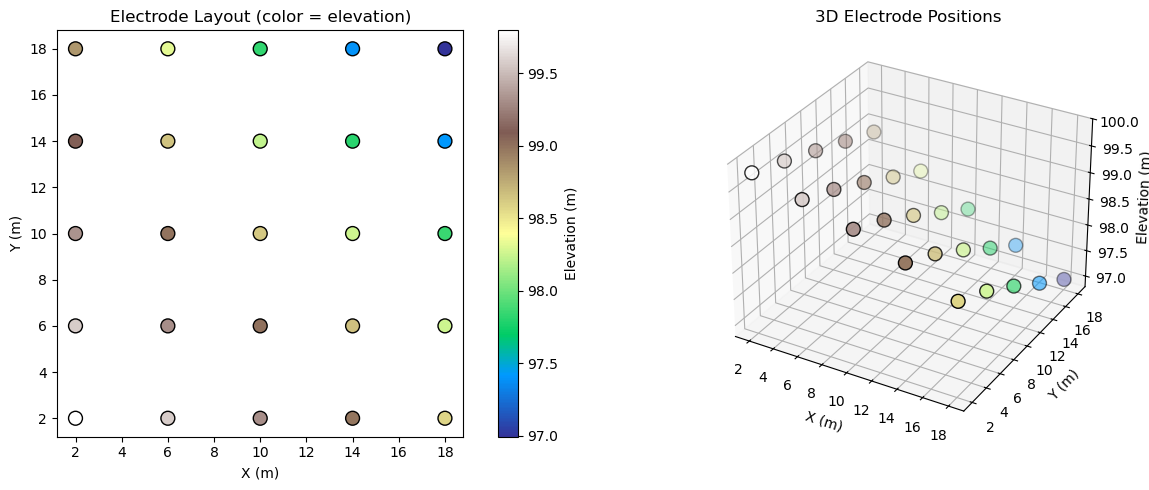

In [101]:
# Visualize electrode layout with topography
fig = plt.figure(figsize=(14, 5))

# 2D Layout
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(
    electrode_positions['x'], 
    electrode_positions['y'],
    c=electrode_positions['z'],
    cmap='terrain',
    s=100,
    edgecolors='black'
)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('Electrode Layout (color = elevation)')
ax1.set_aspect('equal')
plt.colorbar(scatter, ax=ax1, label='Elevation (m)')

# 3D Layout
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(
    electrode_positions['x'], 
    electrode_positions['y'],
    electrode_positions['z'],
    c=electrode_positions['z'],
    cmap='terrain',
    s=100,
    edgecolors='black'
)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_zlabel('Elevation (m)')
ax2.set_title('3D Electrode Positions')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'electrode_layout.png'), dpi=150)
plt.show()

## Step 2: Create 3D Mesh with Topography Using mesh_3d.py

We use the `create_3d_mesh_with_topography()` method from `Mesh3DCreator` to create
a mesh that follows our topographic surface. This ensures accurate ERT modeling
in terrain with elevation changes.

**Key options:**
- `use_prism_mesh=True`: Creates efficient prism mesh (good for layered structures)
- `use_prism_mesh=False`: Creates tetrahedral mesh using PyGIMLi's PLC approach

In [102]:
# Method 1: Create 3D mesh WITH topography using mesh_3d.py
# This creates a mesh that follows the surface elevation

print("Creating 3D mesh with topography using mesh_3d.py...")

# Define marker regions based on depth below surface
depth_markers = {
    'shallow': (0, 5, 2),      # 0-5m depth: marker 2
    'middle': (5, 15, 3),      # 5-15m depth: marker 3  
    'deep': (15, 30, 1)        # >15m depth: marker 1 (boundary)
}

mesh = mesh_creator.create_3d_mesh_with_topography(
    electrode_positions=electrode_positions,
    topography_func=topography_function,
    para_depth=domain_depth,
    boundary_extension=1.4,
    boundary_depth=5.0,
    para_max_cell_size=5.0,
    dz_fine=1.0,
    dz_coarse=2.0,
    use_prism_mesh=True,  # Use prism mesh for efficiency
    markers=depth_markers
)

print(f"Mesh created: {mesh}")
print(f"  Nodes: {mesh.nodeCount()}")
print(f"  Cells: {mesh.cellCount()}")
print(f"  Boundaries: {mesh.boundaryCount()}")

Creating 3D mesh with topography using mesh_3d.py...
Mesh created: Mesh: Nodes: 5056 Cells: 9090 Boundaries: 2247
  Nodes: 5056
  Cells: 9090
  Boundaries: 2247


In [103]:
# Create ERT data container using mesh_3d.py helper function
from PyHydroGeophysX.core.mesh_3d import create_3d_ert_data_container

# Create data container with dipole-dipole scheme
data = create_3d_ert_data_container(
    electrode_positions=electrode_positions,
    scheme='dd',  # dipole-dipole
    dimension=3   # 3D geometric factors
)

print(f"Data container: {data}")
print(f"Number of measurements: {data.size()}")
print(f"Geometric factors calculated for 3D")

Data container: Data: Sensors: 25 data: 253, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']
Number of measurements: 253
Geometric factors calculated for 3D


In [104]:
# Save mesh
mesh.save(os.path.join(output_dir, 'mesh_3d.bms'))
mesh.exportVTK(os.path.join(output_dir, 'mesh_3d.vtk'))
print(f"Mesh saved to {output_dir}")

Mesh saved to results/3d_ert_workflow


## Step 3: Load and Prepare Hydrological Data

Load MODFLOW output (water content, porosity) and prepare for interpolation
to the 3D mesh. The data needs to be defined in the same coordinate system
as the mesh, with z-values relative to the topographic surface.

In [105]:
# Load hydrological data (example using synthetic data)
# Replace with actual MODFLOW data loading

data_dir = "data/"

# Try to load actual data, otherwise create synthetic
try:
    water_content_full = np.load(os.path.join(data_dir, "Watercontent.npy"))
    if water_content_full.ndim == 4:  # (time, nlay, nrow, ncol)
        water_content_3d = water_content_full[0]  # First timestep
    else:
        water_content_3d = water_content_full
    porosity_3d = np.load(os.path.join(data_dir, "Porosity.npy"))
    
    print("Loaded actual MODFLOW data")
    print(f"Full water content shape: {water_content_3d.shape}")
    print(f"Full porosity shape: {porosity_3d.shape}")
    USE_REAL_DATA = True
    
    # Use the optimal MODFLOW offset from domain setup cell
    # MODFLOW_X_OFFSET and MODFLOW_Y_OFFSET define where our domain starts
    x_start = MODFLOW_X_OFFSET
    x_end = MODFLOW_X_OFFSET + int(domain_length)
    y_start = MODFLOW_Y_OFFSET
    y_end = MODFLOW_Y_OFFSET + int(domain_width)
    
    # Get the original dimensions
    modflow_nlay, modflow_nrow, modflow_ncol = water_content_3d.shape
    
    # Ensure bounds are within the data
    x_start = max(0, x_start)
    x_end = min(modflow_ncol, x_end)
    y_start = max(0, y_start)
    y_end = min(modflow_nrow, y_end)
    
    # Crop to region of interest - this region is 100% within active cells
    water_content_3d = water_content_3d[:, y_start:y_end, x_start:x_end]
    porosity_3d = porosity_3d[:, y_start:y_end, x_start:x_end]
    
    print(f"\nCropped to domain region: {water_content_3d.shape}")
    print(f"MODFLOW X range: {x_start} to {x_end} (domain X: 0 to {x_end-x_start} m)")
    print(f"MODFLOW Y range: {y_start} to {y_end} (domain Y: 0 to {y_end-y_start} m)")
    
    # Check for NaN values in cropped region
    nan_count_wc = np.sum(np.isnan(water_content_3d))
    nan_count_por = np.sum(np.isnan(porosity_3d))
    total_cells = water_content_3d.size
    
    print(f"\nData quality check:")
    print(f"  Water content NaN count: {nan_count_wc} / {total_cells} ({nan_count_wc/total_cells*100:.1f}%)")
    print(f"  Porosity NaN count: {nan_count_por} / {total_cells} ({nan_count_por/total_cells*100:.1f}%)")
    
    # Update dimensions for interpolation
    nlay, nrow, ncol = water_content_3d.shape
    print(f"\nFinal dimensions: nlay={nlay}, nrow={nrow}, ncol={ncol}")
    
except FileNotFoundError:
    print("Creating synthetic hydrological data for demonstration...")
    USE_REAL_DATA = False
    
    # Create synthetic 3D water content field
    # Dimensions matching our domain
    nlay, nrow, ncol = int(domain_depth), int(domain_width), int(domain_length)
    
    # Create coordinate arrays
    x = np.linspace(0, domain_length, ncol)
    y = np.linspace(0, domain_width, nrow)
    z = np.linspace(-domain_depth, 0, nlay)  # Depth relative to surface
    
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    
    # Synthetic water content (higher near surface, varies laterally)
    water_content_3d = 0.15 + 0.15 * np.exp(Z.T / 5.0)
    water_content_3d += 0.05 * np.sin(X.T / 10.0) * np.cos(Y.T / 8.0)
    water_content_3d = np.clip(water_content_3d, 0.05, 0.45)
    
    # Synthetic porosity (decreases with depth, some lateral variation)
    porosity_3d = 0.35 + 0.1 * np.exp(Z.T / 10.0)
    porosity_3d += 0.02 * np.sin(X.T / 15.0)
    porosity_3d = np.clip(porosity_3d, 0.1, 0.45)
    
    # Transpose to (nlay, nrow, ncol) format like MODFLOW
    water_content_3d = np.transpose(water_content_3d, (2, 1, 0))
    porosity_3d = np.transpose(porosity_3d, (2, 1, 0))
    
    print(f"Synthetic water content shape: {water_content_3d.shape}")
    print(f"Synthetic porosity shape: {porosity_3d.shape}")

Loaded actual MODFLOW data
Full water content shape: (14, 194, 157)
Full porosity shape: (14, 194, 157)

Cropped to domain region: (14, 20, 20)
MODFLOW X range: 67 to 87 (domain X: 0 to 20 m)
MODFLOW Y range: 85 to 105 (domain Y: 0 to 20 m)

Data quality check:
  Water content NaN count: 0 / 5600 (0.0%)
  Porosity NaN count: 0 / 5600 (0.0%)

Final dimensions: nlay=14, nrow=20, ncol=20


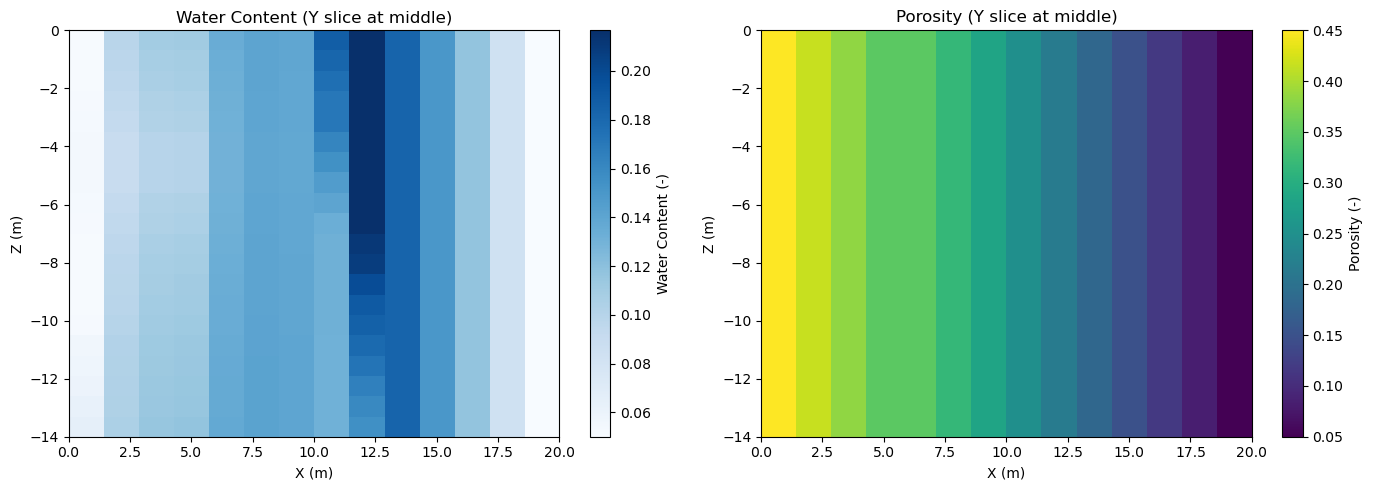

In [106]:
# Visualize a vertical slice of the synthetic data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Water content slice
slice_idx = water_content_3d.shape[2] // 2
im1 = axes[0].imshow(
    water_content_3d[:, :, slice_idx].T,
    extent=[0, domain_length, -domain_depth, 0],
    aspect='auto',
    cmap='Blues',
    origin='lower'
)
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Z (m)')
axes[0].set_title(f'Water Content (Y slice at middle)')
plt.colorbar(im1, ax=axes[0], label='Water Content (-)')

# Porosity slice
im2 = axes[1].imshow(
    porosity_3d[:, :, slice_idx].T,
    extent=[0, domain_length, -domain_depth, 0],
    aspect='auto',
    cmap='viridis',
    origin='lower'
)
axes[1].set_xlabel('X (m)')
axes[1].set_ylabel('Z (m)')
axes[1].set_title(f'Porosity (Y slice at middle)')
plt.colorbar(im2, ax=axes[1], label='Porosity (-)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hydro_data_slices.png'), dpi=150)
plt.show()

## Step 4: Interpolate Hydrological Properties to 3D Mesh

Interpolate the MODFLOW data to mesh cell centers. Since our mesh follows
topography, we need to account for the local surface elevation when
determining the depth of each mesh cell.

In [107]:
from scipy.interpolate import RegularGridInterpolator

# Get mesh cell centers
cell_centers = np.array(mesh.cellCenters())
print(f"Number of mesh cells: {len(cell_centers)}")
print(f"Cell center bounds:")
print(f"  X: [{cell_centers[:,0].min():.2f}, {cell_centers[:,0].max():.2f}]")
print(f"  Y: [{cell_centers[:,1].min():.2f}, {cell_centers[:,1].max():.2f}]")
print(f"  Z: [{cell_centers[:,2].min():.2f}, {cell_centers[:,2].max():.2f}]")

# Calculate depth below local surface for each cell
cell_depths = np.zeros(len(cell_centers))
for i, (x, y, z) in enumerate(cell_centers):
    surface_z = topography_function(x, y)
    cell_depths[i] = surface_z - z  # Positive depth below surface

print(f"\nCell depths range: {cell_depths.min():.2f} to {cell_depths.max():.2f} m")

Number of mesh cells: 9090
Cell center bounds:
  X: [-13.41, 33.45]
  Y: [-13.52, 33.49]
  Z: [77.29, 100.60]

Cell depths range: 0.95 to 18.06 m


In [109]:
# Create grid coordinates for interpolation
# Using depth-relative coordinates (depth below local surface)
nlay, nrow, ncol = water_content_3d.shape

if USE_REAL_DATA:
    # For real MODFLOW data with 1m grid spacing
    # Use full domain coordinates (0 to domain_length/width)
    x_min = 0.0
    x_max = domain_length
    y_min = 0.0
    y_max = domain_width
    
    # Grid spacing (1m for MODFLOW)
    dx = domain_length / ncol
    dy = domain_width / nrow
    
    # Assume depth is domain_depth spread across nlay layers
    dz = domain_depth / nlay
    
    # Cell center coordinates (cell centers, not edges)
    x_coords = np.linspace(dx/2, domain_length - dx/2, ncol)
    y_coords = np.linspace(dy/2, domain_width - dy/2, nrow)
    depth_coords = np.linspace(dz/2, domain_depth - dz/2, nlay)  # Positive depth
else:
    # For synthetic data
    dx = domain_length / ncol
    dy = domain_width / nrow
    dz = domain_depth / nlay
    
    x_coords = np.linspace(dx/2, domain_length - dx/2, ncol)
    y_coords = np.linspace(dy/2, domain_width - dy/2, nrow)
    depth_coords = np.linspace(dz/2, domain_depth - dz/2, nlay)

print(f"Grid coordinates for interpolation:")
print(f"  X: {x_coords[0]:.2f} to {x_coords[-1]:.2f} ({ncol} points)")
print(f"  Y: {y_coords[0]:.2f} to {y_coords[-1]:.2f} ({nrow} points)")
print(f"  Depth: {depth_coords[0]:.2f} to {depth_coords[-1]:.2f} ({nlay} points)")

Grid coordinates for interpolation:
  X: 0.50 to 19.50 (20 points)
  Y: 0.50 to 19.50 (20 points)
  Depth: 0.50 to 13.50 (14 points)


In [110]:
# Create interpolators for water content and porosity
# Handle NaN values in MODFLOW data (inactive cells)
wc_data = water_content_3d.copy()
por_data = porosity_3d.copy()

# Replace NaN values with reasonable defaults
default_wc = 0.15
default_por = 0.30
nan_count_wc = np.isnan(wc_data).sum()
nan_count_por = np.isnan(por_data).sum()

print(f"NaN values in water content: {nan_count_wc} ({100*nan_count_wc/wc_data.size:.1f}%)")
print(f"NaN values in porosity: {nan_count_por} ({100*nan_count_por/por_data.size:.1f}%)")

# Fill NaN with defaults
wc_data = np.nan_to_num(wc_data, nan=default_wc)
por_data = np.nan_to_num(por_data, nan=default_por)

# Reshape data: original is (nlay, nrow, ncol), need (ncol, nrow, nlay) for (x, y, depth)
wc_transposed = np.transpose(wc_data, (2, 1, 0))  # (ncol, nrow, nlay)
por_transposed = np.transpose(por_data, (2, 1, 0))

print(f"Transposed shapes: WC {wc_transposed.shape}, Por {por_transposed.shape}")

wc_interpolator = RegularGridInterpolator(
    (x_coords, y_coords, depth_coords),
    wc_transposed,
    method='linear',
    bounds_error=False,
    fill_value=default_wc
)

por_interpolator = RegularGridInterpolator(
    (x_coords, y_coords, depth_coords),
    por_transposed,
    method='linear',
    bounds_error=False,
    fill_value=default_por
)

# Interpolate to mesh cell centers using (x, y, depth) coordinates
# Create interpolation points: (x, y, depth_below_surface)
interp_points = np.column_stack([
    cell_centers[:, 0],  # x
    cell_centers[:, 1],  # y
    cell_depths          # depth below local surface
])

wc_mesh = wc_interpolator(interp_points)
porosity_mesh = por_interpolator(interp_points)

# Calculate saturation (ensure no division by zero)
porosity_mesh = np.maximum(porosity_mesh, 0.05)  # Minimum porosity
saturation_mesh = np.clip(wc_mesh / porosity_mesh, 0.0, 1.0)

print(f"\nInterpolated values on mesh:")
print(f"  Water content: min={wc_mesh.min():.3f}, max={wc_mesh.max():.3f}")
print(f"  Porosity: min={porosity_mesh.min():.3f}, max={porosity_mesh.max():.3f}")
print(f"  Saturation: min={saturation_mesh.min():.3f}, max={saturation_mesh.max():.3f}")

NaN values in water content: 0 (0.0%)
NaN values in porosity: 0 (0.0%)
Transposed shapes: WC (20, 20, 14), Por (20, 20, 14)

Interpolated values on mesh:
  Water content: min=0.071, max=0.217
  Porosity: min=0.083, max=0.434
  Saturation: min=0.164, max=1.000


## Step 5: Convert Water Content to Resistivity

Use the Waxman-Smits petrophysical model to convert saturation and
porosity to electrical resistivity.

In [111]:
# Petrophysical parameters (Waxman-Smits model)
sigma_w = 0.05  # Conductivity of pore water (S/m) - ~20 Ohm-m
m = 1.5         # Cementation exponent
n = 2.0         # Saturation exponent
sigma_s = 0.001 # Surface conductivity (S/m)

# Convert to resistivity using Waxman-Smits model
# res = 1 / (sigma_w * porosity^m * saturation^n + sigma_s)
resistivity_mesh = WS_Model(
    saturation_mesh,
    porosity_mesh,
    sigma_w,
    m,
    n,
    sigma_s
)

# Ensure valid resistivity values
resistivity_mesh = np.clip(resistivity_mesh, 10, 10000)

print(f"Resistivity on mesh: min={resistivity_mesh.min():.1f} Ohm-m, max={resistivity_mesh.max():.1f} Ohm-m")

Resistivity on mesh: min=194.4 Ohm-m, max=2329.0 Ohm-m


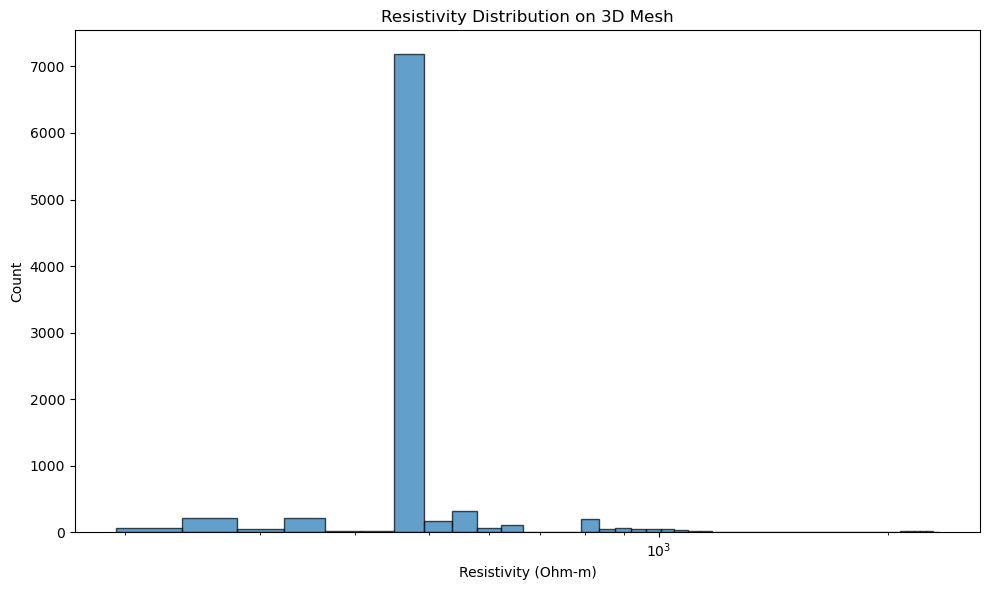

In [112]:
# Visualize resistivity distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(resistivity_mesh, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Resistivity (Ohm-m)')
ax.set_ylabel('Count')
ax.set_title('Resistivity Distribution on 3D Mesh')
ax.set_xscale('log')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'resistivity_histogram.png'), dpi=150)
plt.show()

## Step 6: Perform 3D ERT Forward Modeling

In [113]:
# Create forward modeling operator
fop = ert.ERTModelling()
fop.setData(data)
fop.setMesh(mesh)

print(f"Forward operator configured")
print(f"  Data points: {data.size()}")
print(f"  Model cells: {mesh.cellCount()}")

13/01/26 - 16:52:07 - pyGIMLi - INFO - Found 3 regions.
13/01/26 - 16:52:07 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


Forward operator configured
  Data points: 253
  Model cells: 9090


In [114]:
# Perform forward modeling
print("Running 3D ERT forward modeling...")
response = fop.response(resistivity_mesh)
print(f"Forward modeling complete!")
print(f"Response: min={np.min(response):.2f}, max={np.max(response):.2f} Ohm-m")

13/01/26 - 16:52:11 - pyGIMLi - INFO - Creating forward mesh from region infos.
13/01/26 - 16:52:12 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.


Running 3D ERT forward modeling...


13/01/26 - 16:52:13 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 38347 Cells: 72720 Boundaries: 94044


Forward modeling complete!
Response: min=35.28, max=22626.97 Ohm-m


In [115]:
# Add noise to create synthetic "measured" data
np.random.seed(42)
noise_level = 0.03  # 3% relative error
response_noisy = response * (1.0 + noise_level * np.random.randn(len(response)))

# Store in data container
data['rhoa'] = response_noisy
data['err'] = np.abs(noise_level * response_noisy)  # Absolute error

# Estimate error using ERTManager
mgr = ert.ERTManager(data)
data['err'] = mgr.estimateError(data, relativeError=noise_level, absoluteUError=1e-4)

print(f"Synthetic data with {noise_level*100:.0f}% noise added")

Synthetic data with 3% noise added


In [116]:
# Save synthetic data
data.save(os.path.join(output_dir, 'synthetic_3d_data.dat'))
print(f"Synthetic data saved to {output_dir}/synthetic_3d_data.dat")

Synthetic data saved to results/3d_ert_workflow/synthetic_3d_data.dat


## Step 7: Visualize Results

13/01/26 - 16:53:05 - pyGIMLi - INFO - found 22 x values
13/01/26 - 16:53:05 - pyGIMLi - INFO - found 22 y values
13/01/26 - 16:53:05 - pyGIMLi - INFO - x vector length: 253
13/01/26 - 16:53:05 - pyGIMLi - INFO - y vector length: 253
13/01/26 - 16:53:05 - pyGIMLi - INFO - v vector length: 253


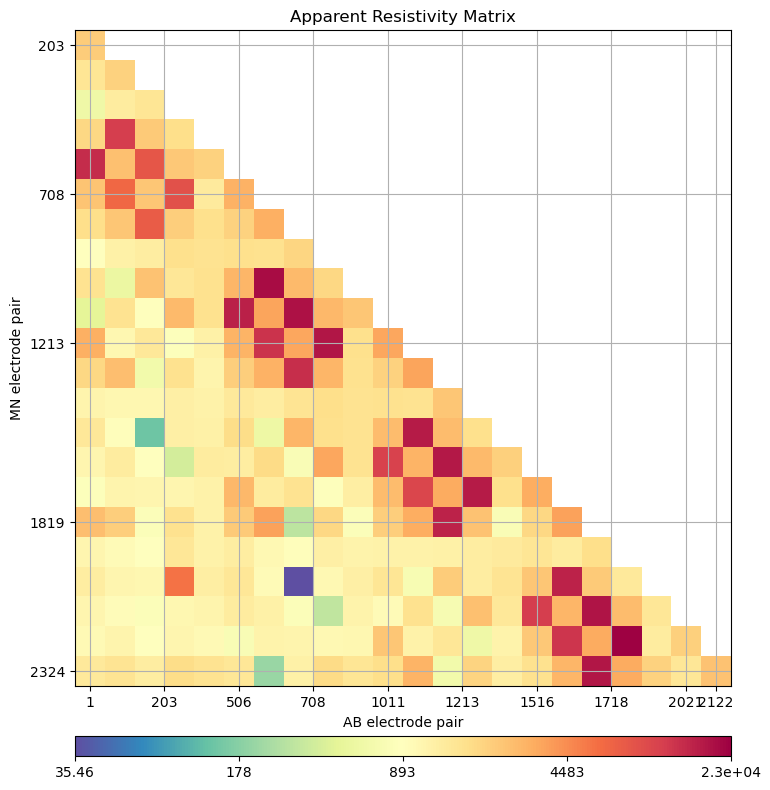

In [117]:
# Visualize apparent resistivity data
from pygimli.viewer.mpl import showDataContainerAsMatrix

# Create pseudo-indices for visualization
ab = data['a'] * 100 + data['b']
mn = data['m'] * 100 + data['n']

fig, ax = plt.subplots(figsize=(10, 8))
ax, cb = showDataContainerAsMatrix(data, ab, mn, 'rhoa', ax=ax, cMap='Spectral_r')
ax.set_xlabel('AB electrode pair')
ax.set_ylabel('MN electrode pair')
ax.set_title('Apparent Resistivity Matrix')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'rhoa_matrix.png'), dpi=150)
plt.show()

Resistivity range (5-95 percentile): 337.8 - 867.3 Ohm-m


c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\plotting\renderer.py:1972: PyVistaDeprecationWarning: `xlabel` is deprecated. Use `xtitle` instead.
  warnings.warn(
c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\plotting\renderer.py:1978: PyVistaDeprecationWarning: `ylabel` is deprecated. Use `ytitle` instead.
  warnings.warn(
c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\plotting\renderer.py:1984: PyVistaDeprecationWarning: `zlabel` is deprecated. Use `ztitle` instead.
  warnings.warn(
c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


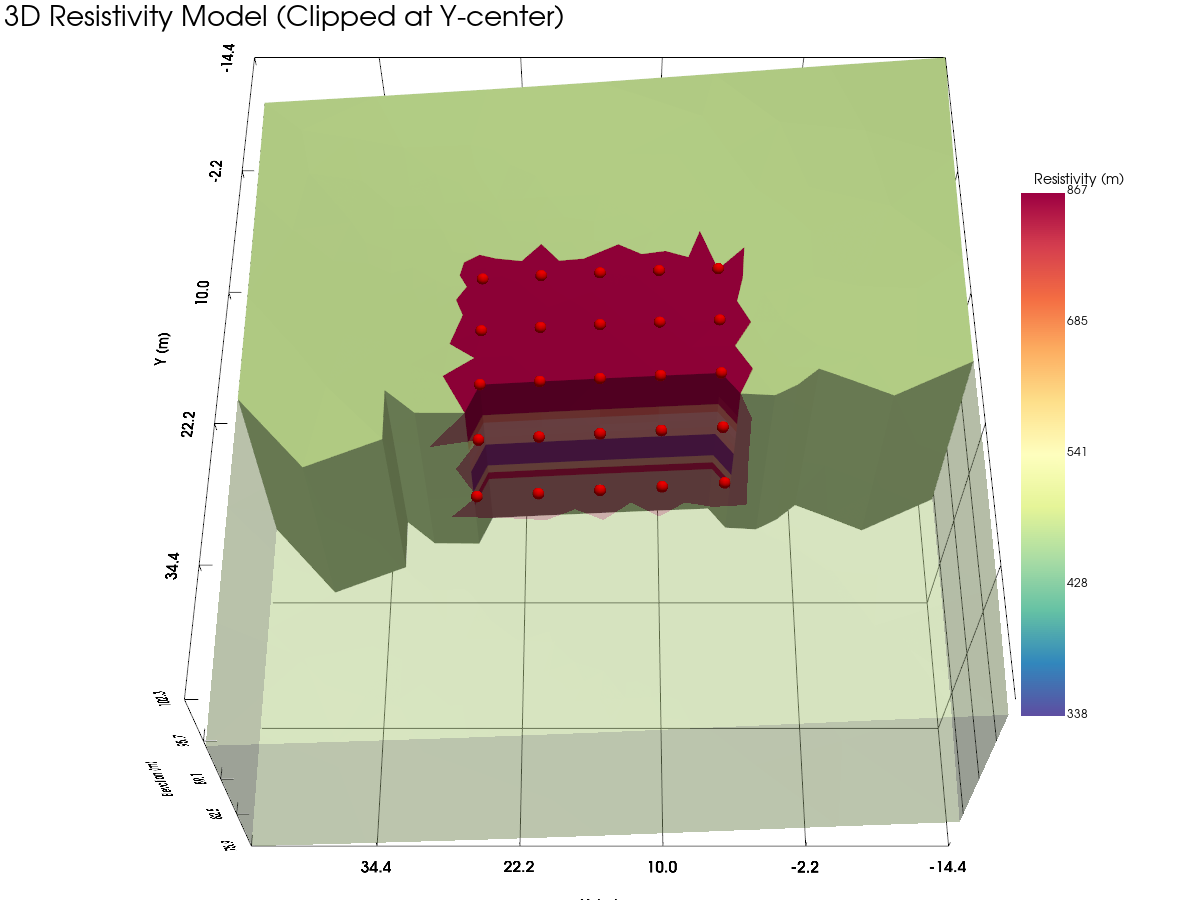

In [118]:
# 3D visualization with PyVista (if available)
if PYVISTA_AVAILABLE:
    # Add resistivity to mesh for visualization
    mesh['resistivity'] = resistivity_mesh
    
    # Convert PyGIMLi mesh to PyVista
    mesh.exportVTK(os.path.join(output_dir, 'mesh_with_res.vtk'))
    pv_mesh = pv.read(os.path.join(output_dir, 'mesh_with_res.vtk'))
    
    # Get data ranges for better color scaling
    res_min, res_max = np.percentile(resistivity_mesh, [5, 95])
    print(f"Resistivity range (5-95 percentile): {res_min:.1f} - {res_max:.1f} Ohm-m")
    
    # Create plotter with better window size
    pl = pv.Plotter(window_size=(1200, 900))
    
    # Add clipped mesh to see internal structure
    # Clip at y = center to show cross-section
    mesh_center = pv_mesh.center
    clipped = pv_mesh.clip(normal='y', origin=mesh_center, crinkle=True)
    
    pl.add_mesh(
        clipped,
        scalars='resistivity',
        cmap='Spectral_r',
        clim=[res_min, res_max],
        log_scale=True,
        show_edges=False,
        scalar_bar_args={
            'title': 'Resistivity (Ωm)',
            'vertical': True,
            'position_x': 0.85,
            'position_y': 0.2,
            'width': 0.1,
            'height': 0.6,
            'fmt': '%.0f',
            'title_font_size': 14,
            'label_font_size': 12
        }
    )
    
    # Add surface mesh with transparency to show topography
    surface = pv_mesh.extract_surface()
    pl.add_mesh(
        surface, 
        scalars='resistivity',
        cmap='Spectral_r',
        clim=[res_min, res_max],
        log_scale=True,
        opacity=0.3,
        show_scalar_bar=False
    )
    
    # Add electrode positions with labels
    electrode_points = electrode_positions[['x', 'y', 'z']].values
    pl.add_points(
        electrode_points, 
        color='red', 
        point_size=12,
        render_points_as_spheres=True
    )
    
    # Add axes and bounds
    pl.show_bounds(
        grid='back',
        location='outer',
        xlabel='X (m)',
        ylabel='Y (m)',
        zlabel='Elevation (m)',
        font_size=12
    )
    
    # Set camera for better view angle
    pl.camera_position = 'iso'
    pl.camera.azimuth = 45
    pl.camera.elevation = 25
    pl.camera.zoom(1.2)
    
    # Add title
    pl.add_text(
        '3D Resistivity Model (Clipped at Y-center)',
        position='upper_left',
        font_size=14,
        color='black'
    )
    
    # Save screenshot
    pl.screenshot(os.path.join(output_dir, '3d_resistivity_model.png'))
    pl.show()
else:
    print("PyVista not available. Skipping 3D visualization.")
    print("Install with: pip install pyvista")

c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


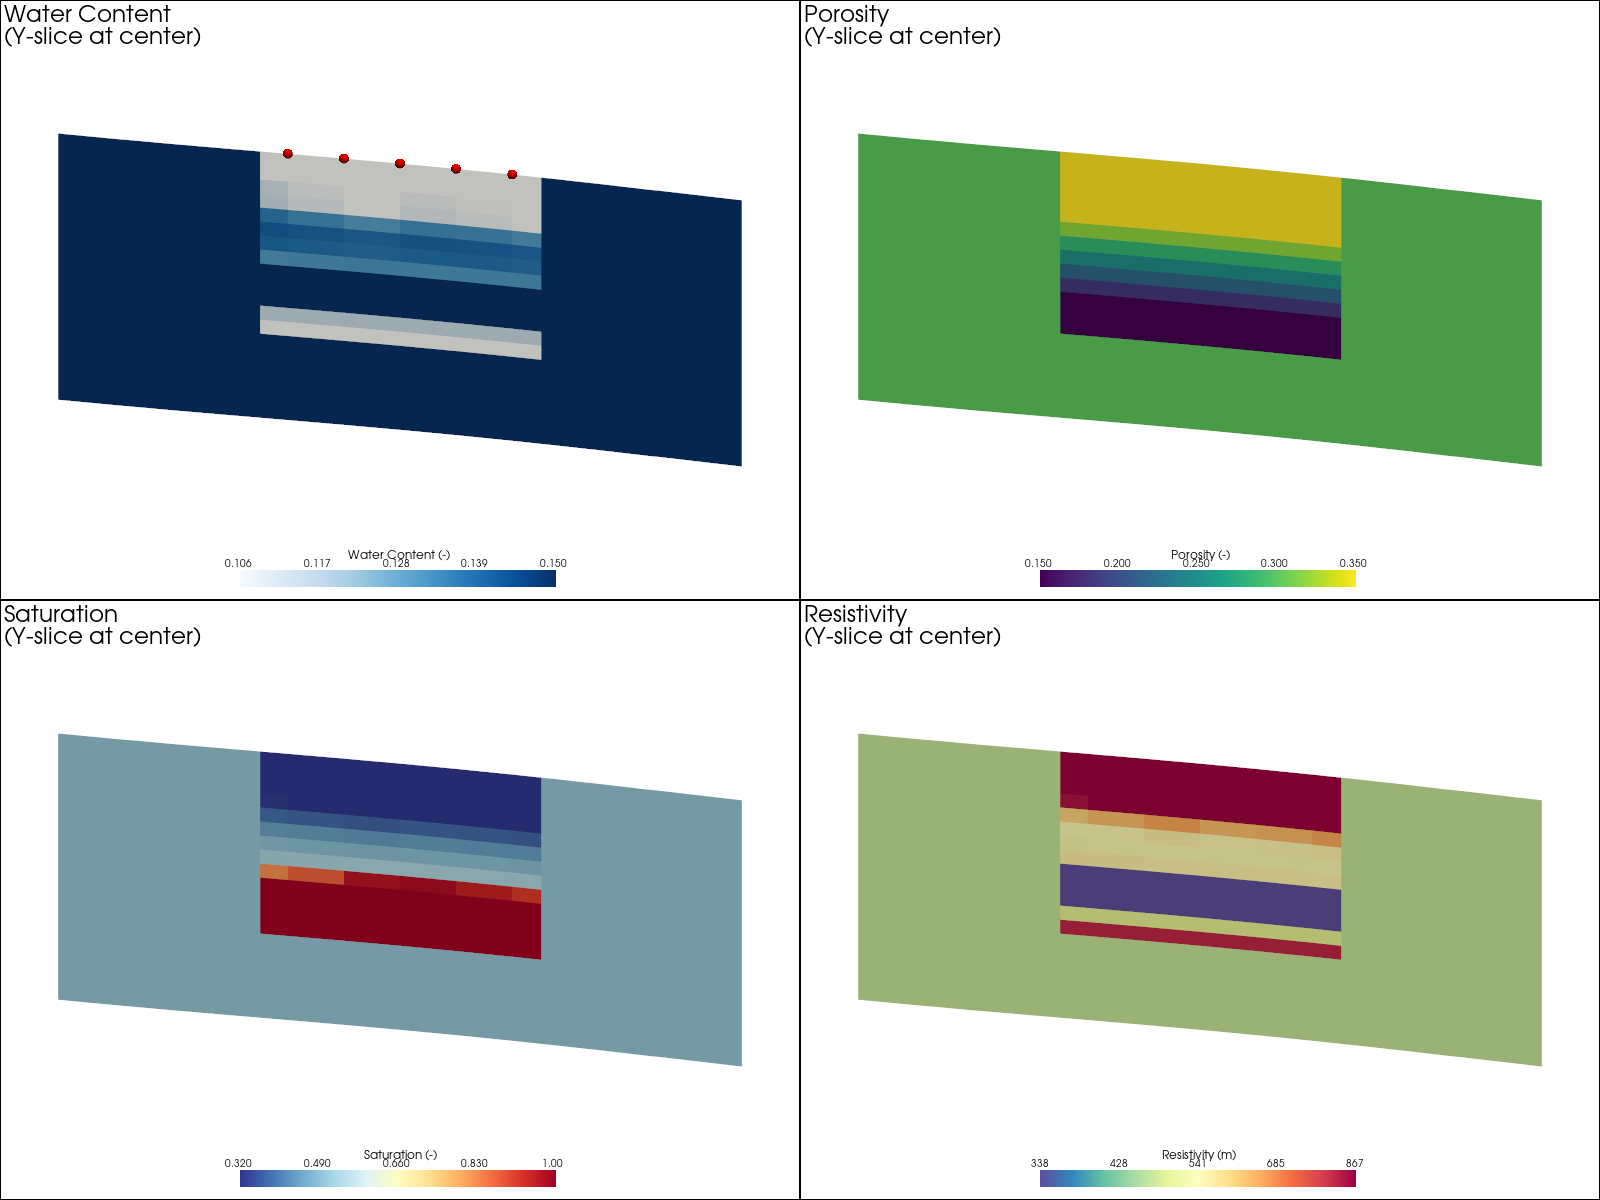


Creating multiple cross-section visualization...


c:\Users\hchen117\.conda\envs\pg\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


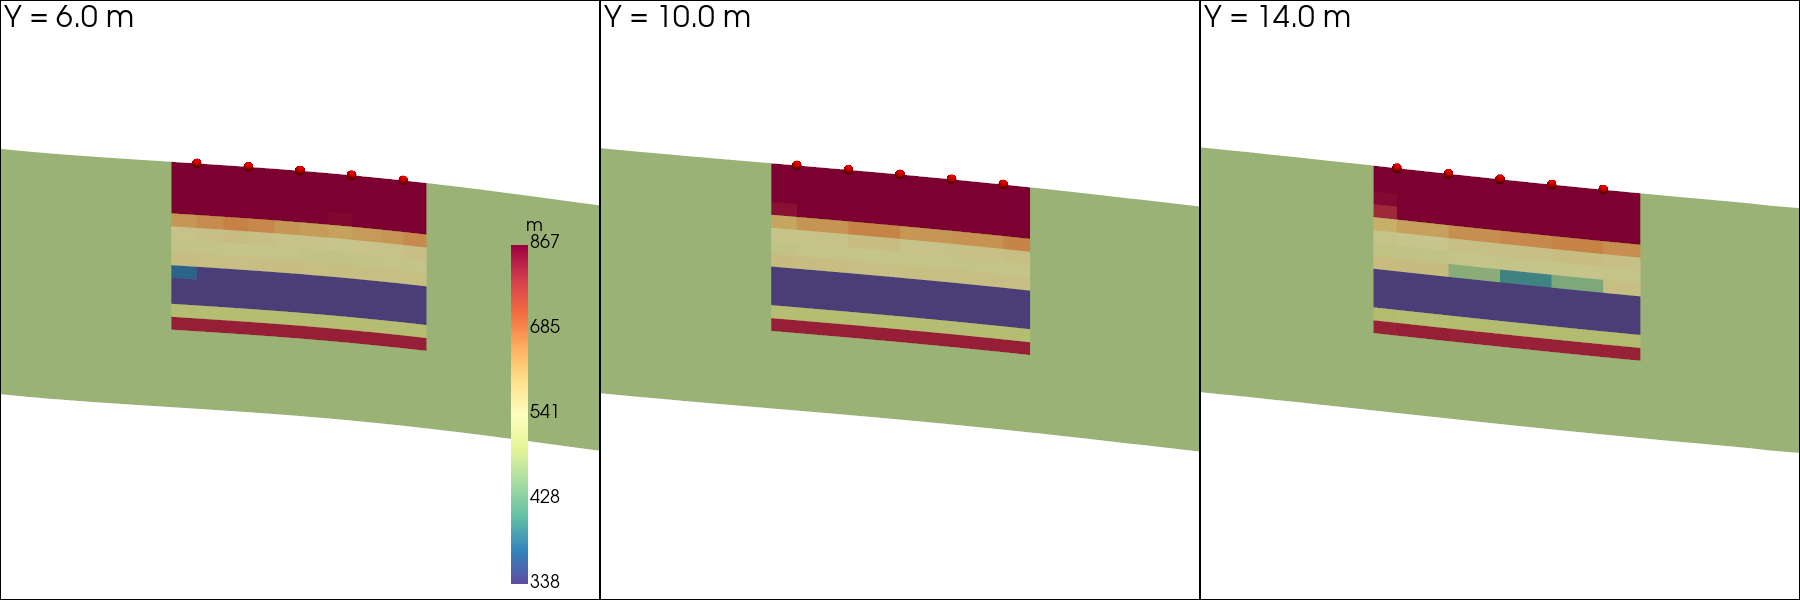

In [125]:
# Create 2D slices for visualization - Multiple cross-sections
if PYVISTA_AVAILABLE:
    # Export mesh with all data
    mesh['water_content'] = wc_mesh
    mesh['porosity'] = porosity_mesh
    mesh['saturation'] = saturation_mesh
    mesh['resistivity'] = resistivity_mesh
    
    mesh.exportVTK(os.path.join(output_dir, 'mesh_with_all_data.vtk'))
    pv_mesh = pv.read(os.path.join(output_dir, 'mesh_with_all_data.vtk'))
    
    # Get data ranges for better color scaling
    wc_range = [np.percentile(wc_mesh, 5), np.percentile(wc_mesh, 95)]
    por_range = [np.percentile(porosity_mesh, 5), np.percentile(porosity_mesh, 95)]
    sat_range = [np.percentile(saturation_mesh, 5), np.percentile(saturation_mesh, 95)]
    res_range = [np.percentile(resistivity_mesh, 5), np.percentile(resistivity_mesh, 95)]
    
    # Create multi-view visualization with better layout
    pl = pv.Plotter(shape=(2, 2), window_size=(1600, 1200))
    
    # Get mesh bounds and electrode bounds for slice positions
    bounds = pv_mesh.bounds
    elec_y_min = electrode_positions['y'].min()
    elec_y_max = electrode_positions['y'].max()
    mesh_center = pv_mesh.center
    
    # Create Y-normal slice at electrode center (shows X-Z cross-section)
    y_slice_pos = (elec_y_min + elec_y_max) / 2
    slice_y = pv_mesh.slice(normal='y', origin=[mesh_center[0], y_slice_pos, mesh_center[2]])
    
    # Common scalar bar settings
    sbar_args = {
        'vertical': False,
        'height': 0.08,
        'width': 0.4,
        'position_x': 0.3,
        'position_y': 0.02,
        'title_font_size': 12,
        'label_font_size': 10,
        'n_labels': 5
    }
    
    # Plot 1: Water Content (top-left)
    pl.subplot(0, 0)
    pl.add_mesh(
        slice_y.copy(), 
        scalars='water_content', 
        cmap='Blues',
        clim=wc_range,
        show_edges=False,
        scalar_bar_args={**sbar_args, 'title': 'Water Content (-)'}
    )
    # Add electrodes projected onto slice
    elec_near_slice = electrode_positions[abs(electrode_positions['y'] - y_slice_pos) < 3]
    if len(elec_near_slice) > 0:
        pl.add_points(elec_near_slice[['x', 'y', 'z']].values, color='red', point_size=10,
                     render_points_as_spheres=True)
    pl.add_text('Water Content\n(Y-slice at center)', position='upper_left', font_size=11)
    pl.view_xz()
    pl.camera.zoom(1.3)
    
    # Plot 2: Porosity (top-right)
    pl.subplot(0, 1)
    pl.add_mesh(
        slice_y.copy(), 
        scalars='porosity', 
        cmap='viridis',
        clim=por_range,
        show_edges=False,
        scalar_bar_args={**sbar_args, 'title': 'Porosity (-)'}
    )
    pl.add_text('Porosity\n(Y-slice at center)', position='upper_left', font_size=11)
    pl.view_xz()
    pl.camera.zoom(1.3)
    
    # Plot 3: Saturation (bottom-left)
    pl.subplot(1, 0)
    pl.add_mesh(
        slice_y.copy(), 
        scalars='saturation', 
        cmap='RdYlBu_r',
        clim=sat_range,
        show_edges=False,
        scalar_bar_args={**sbar_args, 'title': 'Saturation (-)'}
    )
    pl.add_text('Saturation\n(Y-slice at center)', position='upper_left', font_size=11)
    pl.view_xz()
    pl.camera.zoom(1.3)
    
    # Plot 4: Resistivity (bottom-right)
    pl.subplot(1, 1)
    pl.add_mesh(
        slice_y.copy(), 
        scalars='resistivity', 
        cmap='Spectral_r',
        clim=res_range,
        log_scale=True,
        show_edges=False,
        scalar_bar_args={**sbar_args, 'title': 'Resistivity (Ωm)', 'fmt': '%.0f'}
    )
    pl.add_text('Resistivity\n(Y-slice at center)', position='upper_left', font_size=11)
    pl.view_xz()
    pl.camera.zoom(1.3)
    
    # Link all cameras so they move together
    pl.link_views()
    
    # Save and show
    pl.screenshot(os.path.join(output_dir, '2d_slices_properties.png'))
    pl.show()
    
    # === Additional: Multiple X-Z slices at different Y positions ===
    print("\nCreating multiple cross-section visualization...")
    
    # Use 3 Y positions - electrodes are at Y = 2, 6, 10, 14, 18
    y_positions = [6.0, 10.0, 14.0]
    
    pl2 = pv.Plotter(shape=(1, 3), window_size=(1800, 600))
    
    for i, y_pos in enumerate(y_positions):
        pl2.subplot(0, i)
        # Slice at this Y position
        slice_at_y = pv_mesh.slice(normal='y', origin=[mesh_center[0], y_pos, mesh_center[2]])
        
        # Only add mesh if slice has data
        if slice_at_y.n_cells > 0:
            pl2.add_mesh(
                slice_at_y,
                scalars='resistivity',
                cmap='Spectral_r',
                clim=res_range,
                log_scale=True,
                show_edges=False,
                scalar_bar_args={
                    'vertical': True, 
                    'title': 'Ωm', 
                    'position_x': 0.85,
                    'height': 0.6,
                    'width': 0.08,
                    'fmt': '%.0f'
                }
            )
            # Add electrodes near this Y position
            elec_near = electrode_positions[abs(electrode_positions['y'] - y_pos) < 1]
            if len(elec_near) > 0:
                pl2.add_points(elec_near[['x', 'y', 'z']].values, color='red', 
                              point_size=10, render_points_as_spheres=True)
        pl2.add_text(f'Y = {y_pos:.1f} m', position='upper_left', font_size=12)
        pl2.view_xz()
        pl2.camera.zoom(1.2)
    
    # Don't link views here - let each panel have its own view
    pl2.screenshot(os.path.join(output_dir, '2d_slices_multi_y.png'))
    pl2.show()
    
else:
    print("PyVista not available for slice visualization.")

## Step 8: Alternative Mesh Creation Methods

The `mesh_3d.py` module supports multiple mesh creation approaches:

### Option A: Prism Mesh (used above)
- Created with `create_3d_mesh_with_topography(use_prism_mesh=True)`
- Efficient for layered structures
- Triangular prisms extruded from 2D mesh

### Option B: Tetrahedral Mesh
- Created with `create_3d_mesh_with_topography(use_prism_mesh=False)`
- Uses PyGIMLi's `createParaMeshPLC3D`
- Better for complex 3D structures

### Option C: Manual Prism Mesh
- Use `create_prism_mesh_from_2d(mesh2d, z_vector)` for custom control

Below we show the manual approach for comparison:

In [85]:
# Alternative: Manual 2D mesh creation for prism extrusion
# This gives you more control over the 2D base mesh

# Get unique x-y positions from electrodes
xy_positions = electrode_positions[['x', 'y']].drop_duplicates().values

# Create 2D surface mesh using mesh_3d.py
mesh2d = mesh_creator.create_surface_mesh_with_topography(
    electrode_positions=electrode_positions,
    boundary_extension=1.4,
    area=2.0,
    quality=34.3
)

# Add boundary region
boundary_size = 5
mesh2d_with_bnd = mt.appendTriangleBoundary(
    mesh2d, boundary=boundary_size, isSubSurface=False, marker=1
)

print(f"2D base mesh: {mesh2d_with_bnd}")

2D base mesh: Mesh: Nodes: 2165 Cells: 4304 Boundaries: 6468


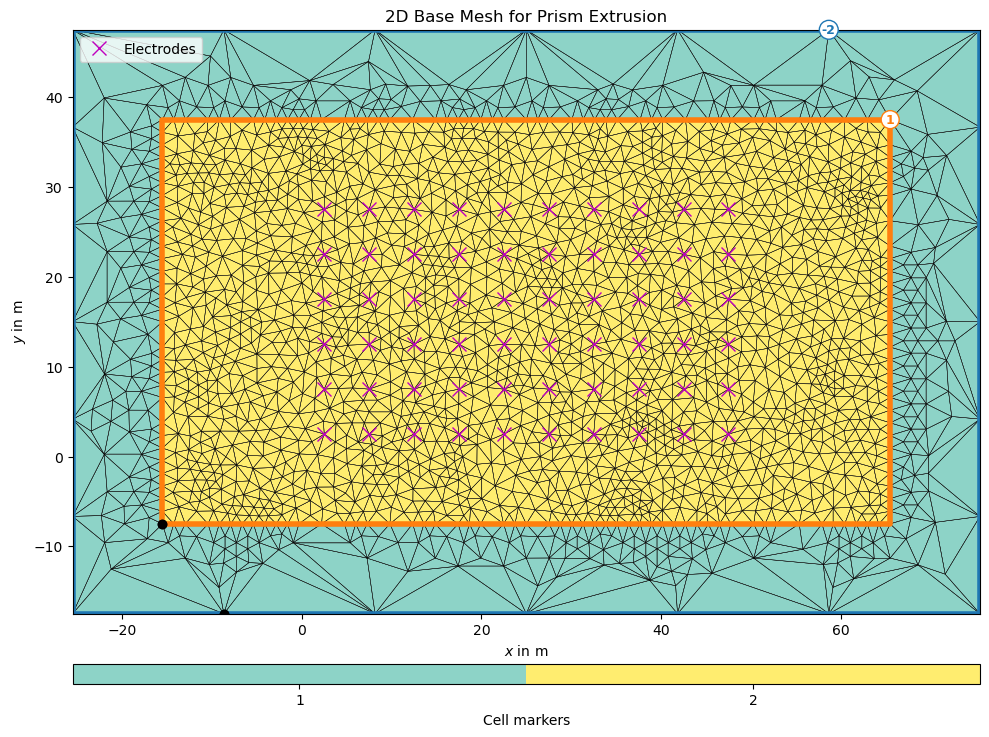

In [86]:
# Visualize 2D mesh
fig, ax = plt.subplots(figsize=(10, 8))
pg.show(mesh2d_with_bnd, markers=True, showMesh=True, ax=ax)
ax.plot(*xy_positions.T, 'mx', markersize=10, label='Electrodes')
ax.legend()
ax.set_title('2D Base Mesh for Prism Extrusion')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '2d_base_mesh.png'), dpi=150)
plt.show()

In [87]:
# Create z-discretization vector
dz_coarse = 2.0  # Coarser spacing for top/bottom
dz_fine = 0.5    # Finer spacing in middle

z_top = np.arange(0, 2, dz_coarse)
z_mid = np.arange(z_top[-1], domain_depth - 2, dz_fine)
z_bot = np.arange(z_mid[-1], domain_depth + boundary_size + 0.1, dz_coarse)

z_vec = -np.concatenate([z_top, z_mid[1:], z_bot[1:]])
print(f"Z-vector: {len(z_vec)} levels from {z_vec.min():.1f} to {z_vec.max():.1f}")

Z-vector: 39 levels from -23.5 to -0.0


In [88]:
# Create 3D prism mesh using mesh_3d.py
mesh3d_prism = mesh_creator.create_prism_mesh_from_2d(
    mesh2d=mesh2d_with_bnd,
    z_vector=z_vec,
    surface_marker=1,
    subsurface_marker=2
)

print(f"3D prism mesh: {mesh3d_prism}")

# Set markers based on depth
depth_top = 2.0  # Top region
depth_bot = domain_depth - 2.0  # Bottom region

for c in mesh3d_prism.cells():
    cd = -c.center().z()  # Center depth (positive)
    if cd < depth_top or cd > depth_bot:
        c.setMarker(1)  # Boundary region

# Save prism mesh
mesh3d_prism.save(os.path.join(output_dir, 'mesh_3d_prism.bms'))
mesh3d_prism.exportVTK(os.path.join(output_dir, 'mesh_3d_prism.vtk'))
print(f"Prism mesh saved to {output_dir}")

3D prism mesh: Mesh: Nodes: 84435 Cells: 163552 Boundaries: 15638
Prism mesh saved to results/3d_ert_workflow


## Summary

This notebook demonstrated:

1. **mesh_3d.py Module Tutorial**: Learned how to use the `Mesh3DCreator` class
2. **Electrode Layout with Topography**: Created surface electrodes following terrain
3. **3D Mesh with Topography**: Used `create_3d_mesh_with_topography()` for realistic terrain
4. **Data Integration**: Interpolated MODFLOW outputs using depth-relative coordinates
5. **Petrophysics**: Converted water content/saturation to resistivity using Waxman-Smits
6. **Forward Modeling**: Computed synthetic 3D ERT response
7. **Visualization**: Created 3D visualizations using PyVista

---

## mesh_3d.py Quick Reference

### Mesh3DCreator Methods

| Method | Description |
|--------|-------------|
| `create_surface_electrode_array(nx, ny, dx, dy, ...)` | Regular grid of surface electrodes |
| `create_borehole_electrode_array(x, y, z_positions)` | Single borehole electrodes |
| `create_crosshole_electrode_array(borehole_positions, z_positions)` | Multiple boreholes |
| `apply_topography_to_electrodes(electrodes, topography_func)` | Set electrode z from topography |
| `create_3d_mesh_with_topography(electrodes, topography_func, ...)` | **Main method for terrain-following mesh** |
| `create_box_mesh(length, width, height, electrodes)` | Simple flat box mesh |
| `create_prism_mesh_from_2d(mesh2d, z_vector)` | Extrude 2D mesh to prisms |
| `visualize_mesh(mesh, electrode_positions)` | 3D visualization with PyVista |

### Helper Functions

| Function | Description |
|----------|-------------|
| `create_3d_ert_data_container(electrodes, scheme, dim)` | Create ERT data with 3D geometric factors |
| `interpolate_modflow_to_3d_mesh(mesh, data, grid)` | Interpolate MODFLOW data to mesh |
| `export_electrodes_to_csv(electrodes, path)` | Save electrodes to CSV |

### Next Steps

- Perform 3D ERT inversion using `ert.ERTManager`
- Compare inverted model with true model
- Analyze resolution and sensitivity
- Time-lapse monitoring applications

In [89]:
print("=" * 60)
print("3D ERT forward modeling workflow complete!")
print("=" * 60)
print(f"\nOutput files saved to: {output_dir}")
print("  - mesh_3d.bms/vtk: Tetrahedral mesh with topography")
print("  - mesh_3d_prism.bms/vtk: Prism mesh")
print("  - synthetic_3d_data.dat: Synthetic ERT data")
print("  - Various visualization plots")
print("\n" + "=" * 60)
print("Key mesh_3d.py functions used:")
print("=" * 60)
print("  - Mesh3DCreator()                        : Initialize mesh creator")
print("  - create_surface_electrode_array()       : Create electrode grid")
print("  - apply_topography_to_electrodes()       : Apply surface elevation")
print("  - create_3d_mesh_with_topography()       : Create terrain-following mesh")
print("  - create_3d_ert_data_container()         : Create ERT data with 3D k-factors")

3D ERT forward modeling workflow complete!

Output files saved to: results/3d_ert_workflow
  - mesh_3d.bms/vtk: Tetrahedral mesh with topography
  - mesh_3d_prism.bms/vtk: Prism mesh
  - synthetic_3d_data.dat: Synthetic ERT data
  - Various visualization plots

Key mesh_3d.py functions used:
  - Mesh3DCreator()                        : Initialize mesh creator
  - create_surface_electrode_array()       : Create electrode grid
  - apply_topography_to_electrodes()       : Apply surface elevation
  - create_3d_mesh_with_topography()       : Create terrain-following mesh
  - create_3d_ert_data_container()         : Create ERT data with 3D k-factors
